In [1]:
import numpy as np
import nengo
import nengo_aie
import sys

import logging
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, format="[%(name)s/%(levelname)s]: %(message)s")

In [2]:
model = nengo.Network()

with model:
    A = nengo.Ensemble(100, dimensions=1)
    A_squared = nengo.Ensemble(100, dimensions=1)
    error = nengo.Ensemble(100, dimensions=1)

    #conn = nengo.Connection(A, A_squared)
    conn = nengo_aie.AIEConnection(A, A_squared)

    conn.learning_rule_type = nengo.PES(learning_rate=3e-4)

    nengo.Connection(error, conn.learning_rule)

    nengo.Connection(A_squared, error)

    nengo.Connection(A, error, function=lambda x: x**2, transform=-1)

In [3]:
with model:
    input_node = nengo.Node(output=lambda t: int(6 * t / 5) / 3.0 % 2 - 1)

    nengo.Connection(input_node, A)

    stop_learning = nengo.Node(output=lambda t: t >= 15)

    nengo.Connection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1)))

In [4]:
with model:
    input_node_probe = nengo.Probe(input_node)
    A_probe = nengo.Probe(A, synapse=0.01)
    A_squared_probe = nengo.Probe(A_squared, synapse=0.01)
    error_probe = nengo.Probe(error, synapse=0.01)
    learn_probe = nengo.Probe(stop_learning, synapse=None)

In [5]:
with nengo_aie.AIESimulator(model) as sim:
    sim.run(20)

[nengo_aie.simulator/INFO]: Initializing simulator
[nengo_aie.builder/INFO]: Initialied builder
[nengo_aie.builder/DEBUG]: Using default builder for Network
[nengo.cache/ERROR]: Decoder cache index corrupted. Reinitializing cache.
Traceback (most recent call last):
  File "/notebooks/nengo-aie/nengo_aie/builder.py", line 16, in build
    build_result = nengo.builder.Builder.build.__func__(AIEBuilder, model, obj, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/nengo/builder/builder.py", line 246, in build
    raise BuildError(f"Cannot build object of type '{type(obj).__name__}'")
nengo.exceptions.BuildError: Cannot build object of type 'Network'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/nengo/cache.py", line 467, in __enter__


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[nengo.simulator/INFO]: Running <Network (unlabeled) at 0x7b5e479555e0>, dt=0.001000 for 20.000000 seconds, or 20000 steps


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[matplotlib.font_manager/DEBUG]: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
[matplotlib.font_manager/DEBUG]: findfont: score(FontEntry(fname='/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[matplotlib.font_manager/DEBUG]: findfont: score(FontEntry(fname='/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[matplotlib.font_manager/DEBUG]: findfont: score(FontEntry(fname='/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
[ma

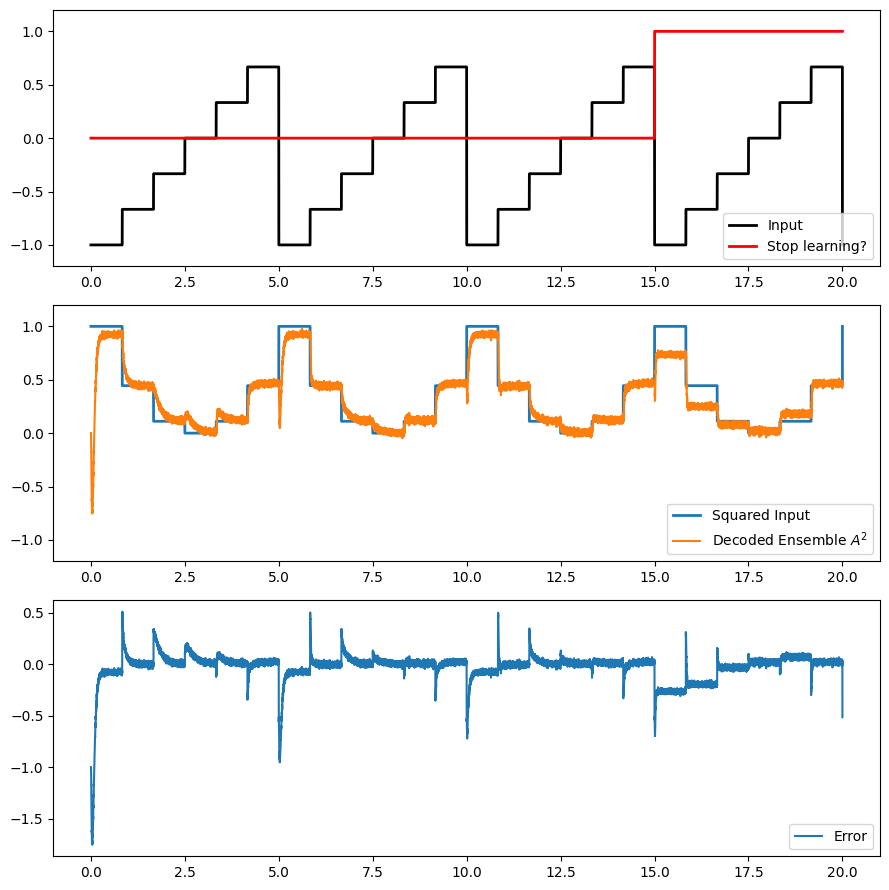

In [6]:
import matplotlib
matplotlib.pyplot.set_loglevel (level = 'warning')

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))
plt.subplot(3, 1, 1)
plt.plot(
    sim.trange(), sim.data[input_node_probe], label="Input", color="k", linewidth=2.0
)
plt.plot(
    sim.trange(),
    sim.data[learn_probe],
    label="Stop learning?",
    color="r",
    linewidth=2.0,
)
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 2)
plt.plot(
    sim.trange(), sim.data[input_node_probe] ** 2, label="Squared Input", linewidth=2.0
)
plt.plot(sim.trange(), sim.data[A_squared_probe], label="Decoded Ensemble $A^2$")
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 3)
plt.plot(
    sim.trange(),
    sim.data[A_squared_probe] - sim.data[input_node_probe] ** 2,
    label="Error",
)
plt.legend(loc="lower right")
plt.tight_layout()

In [ ]:
import nengo
nengo.connection.Connection